In [1]:
import torch

print("cuda available" if torch.cuda.is_available() else "cuda unavailable")
print("gpu ready" if torch.cuda.device_count() else "only cpu")

cuda available
gpu ready


In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

In [3]:
data_path = Path("..") / "data/engineered/training_pop40_genres.parquet"
_df = pd.read_parquet(data_path)
print(f"Loaded {len(_df):,} tracks from {data_path}")

Loaded 561,314 tracks from ../data/engineered/training_pop40_genres.parquet


# Data prep

In [4]:
from ast import literal_eval


df = _df.astype({
    "album_type": "category",
    "_label_size": "float32",
})

if pd.api.types.is_string_dtype(df["_artist_genres"]):
    df["_artist_genres"] = df["_artist_genres"].map(literal_eval)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561314 entries, 0 to 561313
Data columns (total 28 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   track_rowid              561314 non-null  int64   
 1   track_name               561314 non-null  string  
 2   artist_name              561314 non-null  string  
 3   artist_rowid             561314 non-null  int64   
 4   album_rowid              561314 non-null  int64   
 5   album_name               561314 non-null  string  
 6   artist_genres            561314 non-null  string  
 7   _artist_genres           561314 non-null  object  
 8   album_type               561314 non-null  category
 9   _label_size              561314 non-null  float32 
 10  _time_signature_is_four  561314 non-null  bool    
 11  _key_cos                 561314 non-null  float32 
 12  _key_sin                 561314 non-null  float32 
 13  mode                     561314 non-null  bo

##  Indexing genres

In [6]:
from ast import literal_eval

def build_genre_vocab(genres: pd.Series):
    vocab = {}
    for genres in genres:
        for genre in genres:
            if genre not in vocab:
                vocab[genre] = len(vocab)
    return vocab

genre2idx = build_genre_vocab(df["_artist_genres"])
print(f"Found {len(genre2idx)} genres.")

Found 647 genres.


## Counting genres and labels

In [7]:
from collections import Counter

def genre_count(s: pd.Series) -> Counter:
    counter = Counter()
    for gs in s:
        for g in gs:
            counter[g] +=1
    return counter

def label_count(s: pd.Series) -> Counter:
    counter = Counter()
    for l in s:
        counter[l] +=1
    return counter 

In [8]:
def genre_idx_count(s: pd.Series, genre2idx: dict) -> torch.Tensor:
    counter = genre_count(s)
    cs = [-1] * len(genre2idx)
    for g, i in genre2idx.items():
        cs[i] = counter[g]
    assert -1 not in cs
    return torch.Tensor(cs)

genre_idx_counts = genre_idx_count(df["_artist_genres"], genre2idx)

## Train split

We split selecting artists at random to minimize data leakage from duplicate tracks.

In [9]:
np.random.seed(0)

artists_unique = df["artist_rowid"].unique()
nartists_train = int(0.8 * len(artists_unique))
artists_train = np.random.choice(artists_unique, replace=False, size=nartists_train)

_shuffled = df.sample(frac=1, replace=False, ignore_index=True, random_state=0)
train_mask = _shuffled["artist_rowid"].isin(artists_train)
dft = _shuffled[train_mask].reset_index(drop=True)
dfv = _shuffled[~train_mask].reset_index(drop=True)

print(f"train amounts to {100 * len(dft) / len(df):.1f} % of the dataset")

train amounts to 80.2 % of the dataset


## Standardizing numerical features

In [10]:
def minmax(s: pd.Series, r: pd.Series | None=None, vrange:tuple[int, int]=(0, 1)) -> pd.Series:
    if r is None:
        r = s
    a, b = vrange
    return a + (s - r.min()) * (b - a) / (r.max() - r.min())

def zscore(s: pd.Series, r: pd.Series | None=None, mode: str = "mean"):
    if r is None:
        r = s
    if mode == "mean":
        m = r.mean()
    elif mode == "median":
        m = r.median()
    else:
        raise ValueError()
    return (s - m) / r.std()


ZSCORE_COLS = ["tempo", "duration_ms", "danceability", "energy", "_loudness", "liveness", "valence"]
MINMAX_COLS = ["_release_year", "speechiness", "acousticness", "instrumentalness", "_label_size"]

for col in ZSCORE_COLS:
    df[col] = zscore(df[col], dft[col], mode="median")
    
    dfv[col] = zscore(dfv[col], dft[col], mode="median")
    dft[col] = zscore(dft[col], mode="median")

for col in MINMAX_COLS:
    df[col] = minmax(df[col], dft[col], vrange=(-1., 1.))
    
    dfv[col] = minmax(dfv[col], dft[col], vrange=(-1., 1.))
    dft[col] = minmax(dft[col], vrange=(-1., 1.))

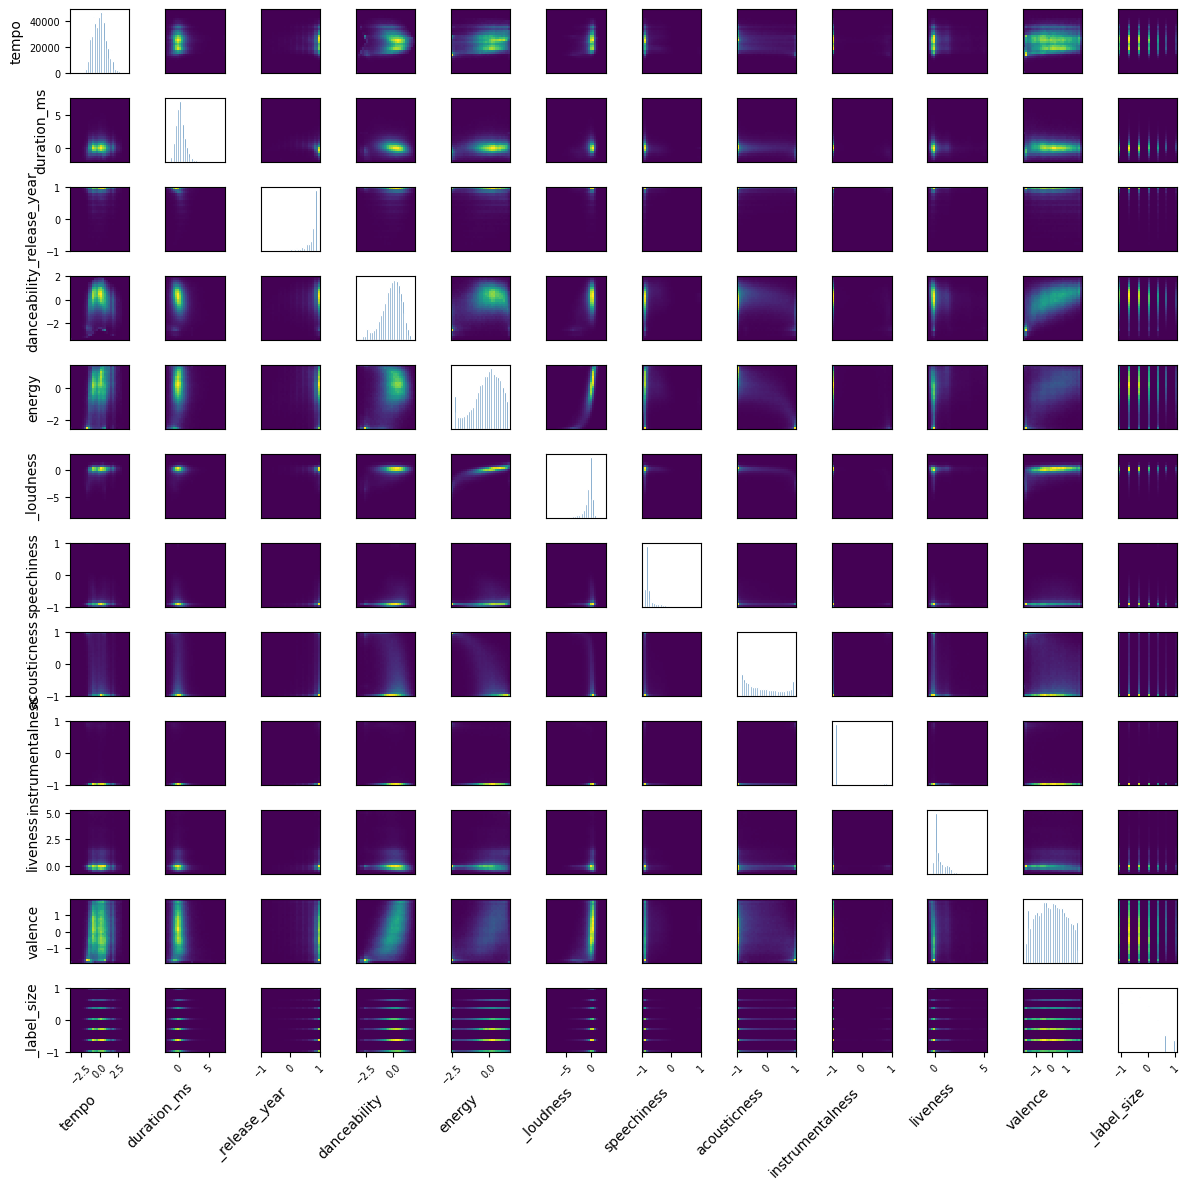

In [11]:
if (_plot_train_correlations := True):
    features = [
        "tempo", "duration_ms", "_release_year", "danceability", "energy",
        "_loudness", "speechiness", "acousticness", "instrumentalness",
        "liveness", "valence", "_label_size",
    ]
    n_feat = len(features)
    fig, axes = plt.subplots(n_feat, n_feat, figsize=(12,12))
    
    for i in range(n_feat):
        for j in range(n_feat):
            ax = axes[i, j]
            if i == j:
                ax.hist(dft[features[i]], bins=30, color='steelblue', edgecolor='white')
            else:
                ax.hist2d(dft[features[j]], dft[features[i]], bins=30)
            
            if i == n_feat - 1:
                ax.set_xlabel(features[j], rotation=45, ha='right')
                ax.tick_params(axis='x', labelsize=7, rotation=45)
            else:
                ax.set_xticks([])
                
            if j == 0:
                ax.set_ylabel(features[i])
                ax.tick_params(axis='y', labelsize=7)
            else:
                ax.set_yticks([])
    
    plt.tight_layout()
    plt.show()

# Dataset

Label size is ordinal-encoded (XXS=0 → XXL=6) and included as a numeric feature. Album type is kept out of training for now.

In [12]:
import torch
from torch.utils.data import Dataset


class TrackDataset(Dataset):
    def __init__(self, df: pd.DataFrame, genre2idx: dict[str, int]):
        # genres multi-hot
        self.genres = torch.zeros(len(df), len(genre2idx), dtype=torch.float32)
        for i, gs in enumerate(df["_artist_genres"]):
            for g in gs:
                self.genres[i, genre2idx[g]] = 1.
        # float variables
        self.numeric = torch.tensor(
            df[[
                "_label_size",
                "_release_year",
                "_release_yday_cos",
                "_release_yday_sin",
                "_key_cos", 
                "_key_sin",
                "mode",
                "tempo",
                "_time_signature_is_four",
                "danceability",
                "energy",
                "_loudness",
                "speechiness",
                "acousticness",
                "instrumentalness",
                "liveness",
                "valence",
                "explicit",
                "duration_ms",
            ]].values.astype(float), 
            dtype=torch.float32
        )
        self._len = len(df)

    def __len__(self):
        return self._len

    def __getitem__(self, idx):
        return (
            self.genres[idx],
            self.numeric[idx],
        )

def collate_fn(batch):
    genres, numeric = zip(*batch)
    return {
        "genres": torch.stack(genres),
        "numeric": torch.stack(numeric),
    }

In [17]:
import torch
from torch import nn

class TrackAutoencoder(nn.Module):
    DIM_HIDDEN1 = 1024
    DIM_HIDDEN2 = 512
    DIM_HIDDEN3 = 256
    DIM_LATENT = 128
    DIM_GENRE_EMBEDDING = 256

    DROPOUT = 0.2
    LEAKY_RELU = 0.1

    def __init__(
        self,
        ngenres: int,
        nnumeric: int,
    ):
        super().__init__()
        self.genre_embedding = nn.Sequential(
            nn.Linear(ngenres, self.DIM_GENRE_EMBEDDING),
            nn.LeakyReLU(self.LEAKY_RELU),
            nn.Dropout(self.DROPOUT),
        )
        dim_in = nnumeric + self.DIM_GENRE_EMBEDDING

        self.encoder = nn.Sequential(
            nn.Linear(dim_in, self.DIM_HIDDEN1),
            nn.LeakyReLU(self.LEAKY_RELU),
            nn.Dropout(self.DROPOUT),
            nn.Linear(self.DIM_HIDDEN1, self.DIM_HIDDEN2),
            nn.LeakyReLU(self.LEAKY_RELU),
            nn.Dropout(self.DROPOUT),
            nn.Linear(self.DIM_HIDDEN2, self.DIM_HIDDEN3),
            nn.LeakyReLU(self.LEAKY_RELU),
            nn.Dropout(self.DROPOUT),
            nn.Linear(self.DIM_HIDDEN3, self.DIM_LATENT),
        )
        self._decoder = nn.Sequential(
            nn.Linear(self.DIM_LATENT, self.DIM_HIDDEN3),
            nn.LeakyReLU(self.LEAKY_RELU),
            nn.Linear(self.DIM_HIDDEN3, self.DIM_HIDDEN2),
            nn.LeakyReLU(self.LEAKY_RELU),
            nn.Linear(self.DIM_HIDDEN2, self.DIM_HIDDEN1),
            nn.LeakyReLU(self.LEAKY_RELU),
        )
        self.head_genres = nn.Linear(self.DIM_HIDDEN1, ngenres)
        self.head_numeric = nn.Linear(self.DIM_HIDDEN1, nnumeric)

    def embed(self, batch: dict[torch.Tensor]) -> torch.Tensor:
        return torch.cat((
            self.genre_embedding(batch["genres"]),
            batch["numeric"],
        ), dim=1)

    def encode(self, batch: dict) -> torch.Tensor:
        return self.encoder(self.embed(batch))
        
    def forward(self, batch: dict):
        zs = self._decoder(self.encode(batch))
        return {
            "genres": self.head_genres(zs),
            "numeric": self.head_numeric(zs),  
        }

# Loss

In [18]:
from typing import Callable


def get_metrics(weights=None, genre_weights=None) -> Callable:
    bce = nn.BCEWithLogitsLoss(pos_weight=genre_weights)
    mse = nn.MSELoss()
    
    wkeys = ["genres", "numeric"]
    if weights is None:
        weights = {}
    elif any([k not in wkeys for k in weights]):
        raise ValueError(f"Wrong key for weights. Allowed keys are: {', '.join(wkeys)}")
    weights |= {k: 1.0 for k in wkeys if k not in weights}

    def compute_batch_metrics(predictions, targets) -> dict:
        # head losses
        l_genres = bce(predictions["genres"], targets["genres"])
        l_numeric = mse(predictions["numeric"], targets["numeric"])
        total = (
            l_numeric * weights["numeric"] +
            l_genres * weights["genres"]
        ) / sum(weights.values())

        # multilabel classifier metrics
        genres_probs = torch.sigmoid(predictions["genres"].detach())
        genres_bpreds = (genres_probs > 0.5).float()
        _tp = (genres_bpreds * targets["genres"]).sum()
        _fp = (genres_bpreds * (1. - targets["genres"])).sum()
        _tn = ((1 - genres_bpreds) * (1. - targets["genres"])).sum()
        _fn = ((1 - genres_bpreds) * targets["genres"]).sum()
        genres_prc = (_tp) / (_tp + _fp)
        genres_rec = (_tp) / (_tp + _fn)
        genres_f1 = 2 * genres_prc * genres_rec / (genres_prc + genres_rec)
        return {
            "total": total,
            "genres": l_genres.item(),
            "numeric": l_numeric.item(),
            "genres_prc": genres_prc.item(),
            "genres_rec": genres_rec.item(),
            "genres_f1": genres_f1.item(),
        }
    
    return compute_batch_metrics

# Training

In [19]:
from torch.utils.data import DataLoader
from torch import optim


print("Creating dataloaders..")
train_dataset = TrackDataset(dft, genre2idx=genre2idx)
valid_dataset = TrackDataset(dfv, genre2idx=genre2idx)
train = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=20, pin_memory=True, collate_fn=collate_fn)
valid = DataLoader(valid_dataset, batch_size=1024, num_workers=20, pin_memory=True, collate_fn=collate_fn)

Creating dataloaders..


In [20]:
import time
from torch.optim.lr_scheduler import ReduceLROnPlateau

torch.set_float32_matmul_precision('high')


def log_epoch(epoch, t, train_metrics, valid_metrics, best_epoch=None, scheduler=None):
    lr_str = f", LR: {scheduler.get_last_lr()[0]:.1e}" if scheduler else ""
    print(f"\n{'='*5} EPOCH {epoch:02d} (Time: {t:.2f}s{lr_str}) {'='*5}")
    
    header = f"{'Metric':<15} | {'Train':<10} | {'Valid':<10}"
    print(header)
    print("-" * len(header))
    
    for key in train_metrics.keys():
        t_val = train_metrics[key]
        v_val = valid_metrics[key]
        print(f"{key.replace('_', ' ').title():<15} | {t_val:<10.5f} | {v_val:<10.5f}")

    if best_epoch == epoch:
        print("* Best epoch so far!")
        

print("Initializing model..")
NEPOCHS, LR = 30, 1e-3
history = []
model = TrackAutoencoder(
    ngenres=len(genre2idx),
    nnumeric=train_dataset.numeric.shape[1],
)
device = torch.device("cuda")
model = model.to(device)
model.compile()
compute_metrics = get_metrics(
    weights={"numeric": 1., "genres": .2},
    genre_weights= (genre_idx_counts.sum() / genre_idx_counts).sqrt().to(device),
)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = ReduceLROnPlateau(optimizer, "min", factor=0.5, patience=3)
best_valid_loss = float("inf")
best_state, best_epoch = None, -1
t0 = time.time()
print(f"Training on {len(train_dataset)} rows..")
for epoch in range(NEPOCHS):
    model.train()
    train_metrics = {}
    
    for batch in train:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()

        xs = model(batch)
        batch_metrics = compute_metrics(xs, batch)
        batch_metrics["total"].backward()
        optimizer.step()
        
        for k in batch_metrics.keys():
            val = batch_metrics[k]
            train_metrics.setdefault(k, 0.)
            train_metrics[k] += val.item() if isinstance(val, torch.Tensor) else val
            
    model.eval()
    valid_metrics = {}
    with torch.no_grad():
        for batch in valid:
            batch = {k: v.to(device) for k, v in batch.items()}
            xs = model(batch)
            batch_metrics = compute_metrics(xs, batch)
            
            for k in batch_metrics.keys():
                val = batch_metrics[k]
                valid_metrics.setdefault(k, 0.)
                valid_metrics[k] += val.item() if isinstance(val, torch.Tensor) else val
    
    scheduler.step(valid_metrics["total"])
    avg_train = {k: v / len(train) for k, v in train_metrics.items()}
    avg_valid = {k: v / len(valid) for k, v in valid_metrics.items()}
    if avg_valid["total"] < best_valid_loss:
        best_valid_loss = avg_valid["total"]
        best_epoch = epoch
        best_state = model.state_dict()
    if epoch % (PRINT_EVERY := 1) == 0: 
        log_epoch(epoch, time.time() - t0, avg_train, avg_valid, best_epoch, scheduler)
        history.append((avg_train, avg_valid))
    if scheduler.get_last_lr()[0] <= 2e-6:
        print("Minimum LR reached. Breaking.")
        break
        
model.load_state_dict(best_state)
print(f"Restored best model (valid loss: {best_valid_loss:.5f}, epoch: {best_epoch})")

Initializing model..
Training on 449921 rows..


W0208 22:06:18.848000 287672 torch/_inductor/utils.py:1250] [1/0] Not enough SMs to use max_autotune_gemm mode



===== EPOCH 00 (Time: 10.37s, LR: 1.0e-03) =====
Metric          | Train      | Valid     
-----------------------------------------
Total           | 0.12904    | 0.03186   
Genres          | 0.18819    | 0.12558   
Numeric         | 0.11722    | 0.01311   
Genres Prc      | 0.19197    | 0.14160   
Genres Rec      | 0.26483    | 0.48661   
Genres F1       | 0.18915    | 0.21931   
* Best epoch so far!

===== EPOCH 01 (Time: 14.71s, LR: 1.0e-03) =====
Metric          | Train      | Valid     
-----------------------------------------
Total           | 0.03462    | 0.01988   
Genres          | 0.09387    | 0.07412   
Numeric         | 0.02277    | 0.00904   
Genres Prc      | 0.16374    | 0.19075   
Genres Rec      | 0.63636    | 0.76532   
Genres F1       | 0.26016    | 0.30536   
* Best epoch so far!

===== EPOCH 02 (Time: 19.07s, LR: 1.0e-03) =====
Metric          | Train      | Valid     
-----------------------------------------
Total           | 0.02555    | 0.01400   
Genres    

# Profiling

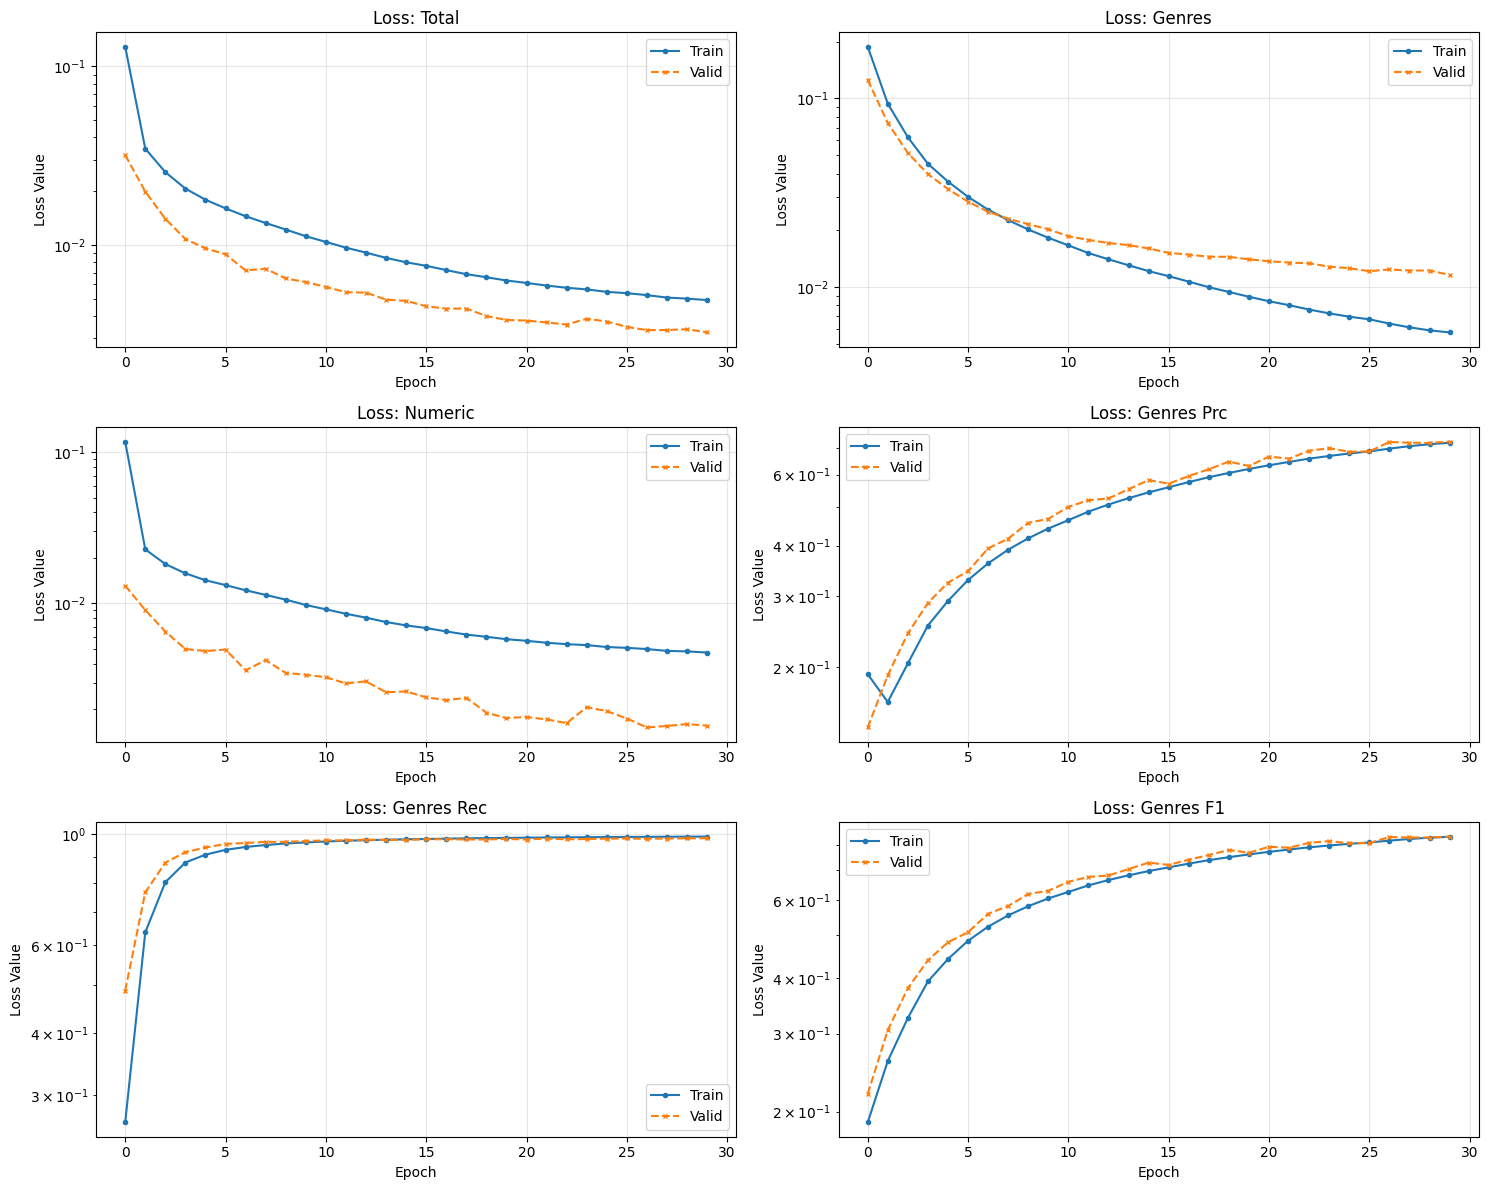

In [24]:
import matplotlib.pyplot as plt


def plot_training_results(history):
    metrics = list(history[0][0].keys())
    num_metrics = len(metrics)
    
    cols = 2
    rows = (num_metrics + 1) // 2
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        train_vals = [h[0][metric] for h in history]
        valid_vals = [h[1][metric] for h in history]
        
        ax = axes[i]
        ax.plot(train_vals, label="Train", marker="o", markersize=3)
        ax.plot(valid_vals, label="Valid", linestyle="--", marker="x", markersize=3)
        
        title = metric.replace("_", " ").title()
        ax.set_title(f"Loss: {title}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss Value")
        ax.semilogy()
        ax.legend()
        ax.grid(True, alpha=0.3)
        if train_vals[0] / (train_vals[-1] + 1e-9) > 100:
            ax.set_yscale("log")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Use it like this:
plot_training_results(history)

In [25]:
import torch.nn.functional as F


def get_recommender(
    model: nn.Module, 
    device: torch.device, 
    df: pd.DataFrame, 
    genre2idx: dict, 
):
    embeddings = [None]
    
    @torch.no_grad()
    def get_all_embeddings():
        dataset = TrackDataset(df, genre2idx=genre2idx)
        dl = DataLoader(dataset, batch_size=1024, shuffle=False, num_workers=20, collate_fn=collate_fn)
        ys = []
        model.eval()
        for batch in dl:
            batch = {k: v.to(device) for k, v in batch.items()}
            ys.append(model.encode(batch))
        return torch.cat(ys, dim=0)

    def recommend(artist: str, track: str, n=10):
        match = df[(df["artist_name"] == artist) & (df["track_name"] == track)]
        if match.empty: 
            return "Track not found."
        idx = match.index[0]
        query_vec = Z[idx].unsqueeze(0)
        sim = F.cosine_similarity(query_vec, Z)
        scores, top_indices = torch.topk(sim, k=n+1)
        similiar_df = df.iloc[top_indices[1:].cpu()]
        return pd.DataFrame({
            "artist_name": similiar_df["artist_name"],
            "track_name": similiar_df["track_name"],
            "score": scores.cpu()[1:],
        })
        
    Z = get_all_embeddings()        
    return recommend

recommend = get_recommender(model, device, df, genre2idx)

In [30]:
recommend("MF DOOM", "Doomsday", 10)

,artist_name,track_name,score
402407,People Under The Stairs,San Francisco Knights,0.941374
473986,MF DOOM,Red and Gold,0.892914
115463,JAY-Z,Money Ain't A Thang,0.891912
511017,Mos Def,Mathematics,0.883668
311,Mos Def,New World Water,0.883119
208347,MF DOOM,"Tick, Tick...",0.878980
247571,A Tribe Called Quest,God Lives Through,0.878676
254945,Jedi Mind Tricks,Blood In Blood Out,0.874163
147441,Talib Kweli,Never Been In Love,0.872984
172857,Xzibit,What U See Is What U Get,0.872609
